In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import rasterio as rio
from rasterio.plot import reshape_as_image, reshape_as_raster
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap
from kneed import KneeLocator
import pandas as pd
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import matplotlib.colors as colors
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, Dataset, DataLoader, Subset
import torch.nn.functional as F
import sys

In [3]:
"""
def apply_mask(image_path, mask_path):
    # Preparing image
    raster_img = rio.open(image_path)                  # get image with image path
    arr_img = reshape_as_image(raster_img.read())      # turn it into an array
    mask_norm = np.all((arr_img >= 0) & (arr_img <= 1), axis=2)
    mask_zero = np.all(arr_img == 0, axis=2)
    arr_img[(~mask_norm) | (mask_zero)] = np.nan
    image = reshape_as_raster(arr_img)
    l, m, n = image.shape                              # check the size of the image 
    #print("Size of the image is "+str(l)+"x"+str(m)+"x"+str(n))
    X = image.reshape(l, -1).T                         # image reshaped as (mxn), l
    scaler = StandardScaler()                                     
    X_scaled = scaler.fit_transform(X)                 # scale the data

    # Preparing mask
    with rio.open(mask_path) as src:
        image = src.read(1)                            # Lire la première bande
    mask_soil = (image > 0).astype(np.uint8)           # 0 is mask, 1 is image
    
    unique, counts = np.unique(mask_soil, return_counts=True)
    print(dict(zip(unique, counts)))
    
    mask_soil_elargi = mask_soil[:,:,np.newaxis]       # so the mask covers all of the spectral bands
    vec_new = np.repeat(mask_soil_elargi,  X_scaled.shape[1], axis=2)  # shape = (m, n, l)
    X_scaled_soil = X_scaled.reshape(m,n,l)*vec_new    # reshape the image to apply the mask correctly
    RED = X_scaled_soil[:, :, 2]
    GREEN = X_scaled_soil[:, :, 1]
    BLUE = X_scaled_soil[:, :, 0]
    rgb = np.stack([RED, GREEN, BLUE], axis=-1)
    print(rgb.shape, len(rgb), rgb.shape[0]*rgb.shape[1]*rgb.shape[2])
    print("count is", abs(np.count_nonzero(rgb) - rgb.shape[0]*rgb.shape[1]*rgb.shape[2]))
    
    min_val = np.nanmin(rgb, axis=(0,1))               # normalize band by band
    max_val = np.nanmax(rgb, axis=(0,1))               
    scale = max_val - min_val                          # Avoid to divide by 0
    scale[scale == 0] = 1                              # change 0 by 1 to avoid warnings
    rgb_norm = (rgb - min_val) / scale                 # normalize the rgb image
    
    plt.imshow(rgb_norm)
    plt.axis('off')
    plt.show()
    return rgb_norm
"""

'\ndef apply_mask(image_path, mask_path):\n    # Preparing image\n    raster_img = rio.open(image_path)                  # get image with image path\n    arr_img = reshape_as_image(raster_img.read())      # turn it into an array\n    mask_norm = np.all((arr_img >= 0) & (arr_img <= 1), axis=2)\n    mask_zero = np.all(arr_img == 0, axis=2)\n    arr_img[(~mask_norm) | (mask_zero)] = np.nan\n    image = reshape_as_raster(arr_img)\n    l, m, n = image.shape                              # check the size of the image \n    #print("Size of the image is "+str(l)+"x"+str(m)+"x"+str(n))\n    X = image.reshape(l, -1).T                         # image reshaped as (mxn), l\n    scaler = StandardScaler()                                     \n    X_scaled = scaler.fit_transform(X)                 # scale the data\n\n    # Preparing mask\n    with rio.open(mask_path) as src:\n        image = src.read(1)                            # Lire la première bande\n    mask_soil = (image > 0).astype(np.uint8)   

In [4]:
def apply_mask(image_path, mask_path):
    # --- Image ---
    raster_img = rio.open(image_path)
    arr_img = reshape_as_image(raster_img.read())  # (m, n, l)

    # On ne met NaN que pour les pixels hors [0,1] (les zéros restent)
    mask_norm = np.all((arr_img >= 0) & (arr_img <= 1), axis=2)
    arr_img[~mask_norm] = np.nan

    image = reshape_as_raster(arr_img)
    l, m, n = image.shape

    X = image.reshape(l, -1).T
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- Masque ---
    with rio.open(mask_path) as src:
        mask_band = src.read(1)                 # (m, n)
    mask_soil = (mask_band > 0).astype(np.uint8)  # 1 = zone affichée, 0 = fond

    mask_soil_elargi = mask_soil[:, :, np.newaxis]          # (m, n, 1)
    vec_new = np.repeat(mask_soil_elargi, X_scaled.shape[1], axis=2)  # (m, n, l)

    X_scaled_soil = X_scaled.reshape(m, n, l) * vec_new

    # --- RGB ---
    RED   = X_scaled_soil[:, :, 2]
    GREEN = X_scaled_soil[:, :, 1]
    BLUE  = X_scaled_soil[:, :, 0]
    rgb = np.stack([RED, GREEN, BLUE], axis=-1)   # (m, n, 3)

    # --- Normalisation canal par canal ---
    min_val = np.nanmin(rgb, axis=(0, 1))
    max_val = np.nanmax(rgb, axis=(0, 1))
    scale = max_val - min_val
    scale[scale == 0] = 1
    rgb_norm = (rgb - min_val) / scale

    # --- FORCER le fond à noir ---
    # mask_soil == 0 -> fond, on les met à (0,0,0)
    fond = (mask_soil == 0)           # (m, n) bool
    rgb_norm[fond] = 0.0              # broadcasting sur la 3ème dimension

    plt.imshow(rgb_norm)
    plt.axis('off')
    plt.show()

    return rgb_norm, fond

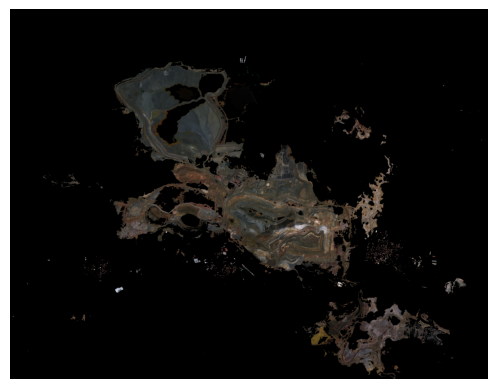

In [5]:
soil_only, fond_soil = apply_mask(r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_10m.img',
                       r"./mask_total_soil_VSWIR_10m.img")

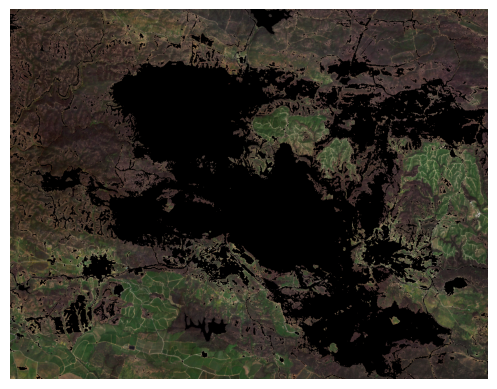

In [6]:
vegetation_only, fond_vegetation = apply_mask(r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_10m.img',
                             r"./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_mask_veg.img")

In [7]:
'''def compute_ndvi(nir, red):
    nir = nir.astype(float)
    red = red.astype(float)
    
    ndvi = (nir - red) / (nir + red)
    
    # Évite les divisions par zéro
    ndvi = np.where((nir + red) == 0, 0, ndvi)
    
    return ndvi, nir

# Exemple d'utilisation :
ndvi, nir = compute_ndvi(image[-1,:,:], image[2,:,:])'''

"def compute_ndvi(nir, red):\n    nir = nir.astype(float)\n    red = red.astype(float)\n    \n    ndvi = (nir - red) / (nir + red)\n    \n    # Évite les divisions par zéro\n    ndvi = np.where((nir + red) == 0, 0, ndvi)\n    \n    return ndvi, nir\n\n# Exemple d'utilisation :\nndvi, nir = compute_ndvi(image[-1,:,:], image[2,:,:])"

In [8]:
'''
# Seuil NDVI (à ajuster selon ton cas)
threshold_ndvi = 0.3
#threshold_nir = 2800

# Mask binaire : 1 = végétation, 0 = non-végétation
veg_mask = (ndvi > threshold_ndvi) #& (nir > threshold_nir)

# On étend le mask en 3D pour l’appliquer aux bandes
veg_mask_3d = veg_mask[None, :, :]  # shape -> (H, W, 1)

# Array final : mêmes dimensions, pixels non végétation = 0
veg_only = np.where(veg_mask_3d, image, 0)

# Indices Sentinel-2 : (si image = [B1, B2, B3, B4, B5, ...])
RED   = veg_only[2, :, :]
GREEN = veg_only[1, :, :]
BLUE  = veg_only[0, :, :]

rgb = np.stack([RED, GREEN, BLUE], axis=-1)

# Normalisation bande par bande
min_val = np.nanmin(rgb, axis=(0,1))
max_val = np.nanmax(rgb, axis=(0,1))

# Évite division par zéro
scale = max_val - min_val
scale[scale == 0] = 1  # remplacer 0 par 1 pour éviter le warning

rgb_norm = (rgb - min_val) / scale

plt.imshow(rgb_norm)
plt.axis('off')
plt.show()
'''

"\n# Seuil NDVI (à ajuster selon ton cas)\nthreshold_ndvi = 0.3\n#threshold_nir = 2800\n\n# Mask binaire : 1 = végétation, 0 = non-végétation\nveg_mask = (ndvi > threshold_ndvi) #& (nir > threshold_nir)\n\n# On étend le mask en 3D pour l’appliquer aux bandes\nveg_mask_3d = veg_mask[None, :, :]  # shape -> (H, W, 1)\n\n# Array final : mêmes dimensions, pixels non végétation = 0\nveg_only = np.where(veg_mask_3d, image, 0)\n\n# Indices Sentinel-2 : (si image = [B1, B2, B3, B4, B5, ...])\nRED   = veg_only[2, :, :]\nGREEN = veg_only[1, :, :]\nBLUE  = veg_only[0, :, :]\n\nrgb = np.stack([RED, GREEN, BLUE], axis=-1)\n\n# Normalisation bande par bande\nmin_val = np.nanmin(rgb, axis=(0,1))\nmax_val = np.nanmax(rgb, axis=(0,1))\n\n# Évite division par zéro\nscale = max_val - min_val\nscale[scale == 0] = 1  # remplacer 0 par 1 pour éviter le warning\n\nrgb_norm = (rgb - min_val) / scale\n\nplt.imshow(rgb_norm)\nplt.axis('off')\nplt.show()\n"

In [9]:
'''
# Pixels restants (non-végétation)
non_veg_mask = ~veg_mask

# Extraire bandes nécessaires
green = image[1, :, :]  # B3
nir   = image[-1, :, :]  # B8

# Calcul NDWI
ndwi = (green - nir) / (green + nir)
ndwi = np.where((green + nir) == 0, 0, ndwi)

# Détection de l'eau
threshold_ndwi = 0  # à ajuster
water_mask = (ndwi > threshold_ndwi) & non_veg_mask

# Étendre le masque sur les bandes
water_mask_3d = water_mask[None, :, :]

# Pixels eau gardés, autres = 0
water_only = np.where(water_mask_3d, image, 0)

RED   = water_only[2, :, :] #+ veg_only[2, :, :]
GREEN = water_only[1, :, :] #+ veg_only[1, :, :]
BLUE  = water_only[0, :, :] #+ veg_only[0, :, :]

rgb_water = np.stack([RED, GREEN, BLUE], axis=-1)

# Normalisation bande par bande
min_val = np.nanmin(rgb_water, axis=(0,1))
max_val = np.nanmax(rgb_water, axis=(0,1))
scale = max_val - min_val
scale[scale == 0] = 1
rgb_norm = (rgb_water - min_val) / scale

plt.imshow(rgb_norm)
plt.axis('off')
plt.show()
'''

"\n# Pixels restants (non-végétation)\nnon_veg_mask = ~veg_mask\n\n# Extraire bandes nécessaires\ngreen = image[1, :, :]  # B3\nnir   = image[-1, :, :]  # B8\n\n# Calcul NDWI\nndwi = (green - nir) / (green + nir)\nndwi = np.where((green + nir) == 0, 0, ndwi)\n\n# Détection de l'eau\nthreshold_ndwi = 0  # à ajuster\nwater_mask = (ndwi > threshold_ndwi) & non_veg_mask\n\n# Étendre le masque sur les bandes\nwater_mask_3d = water_mask[None, :, :]\n\n# Pixels eau gardés, autres = 0\nwater_only = np.where(water_mask_3d, image, 0)\n\nRED   = water_only[2, :, :] #+ veg_only[2, :, :]\nGREEN = water_only[1, :, :] #+ veg_only[1, :, :]\nBLUE  = water_only[0, :, :] #+ veg_only[0, :, :]\n\nrgb_water = np.stack([RED, GREEN, BLUE], axis=-1)\n\n# Normalisation bande par bande\nmin_val = np.nanmin(rgb_water, axis=(0,1))\nmax_val = np.nanmax(rgb_water, axis=(0,1))\nscale = max_val - min_val\nscale[scale == 0] = 1\nrgb_norm = (rgb_water - min_val) / scale\n\nplt.imshow(rgb_norm)\nplt.axis('off')\nplt.show

In [10]:
'''non_water_mask = ~water_mask
soil_mask = non_veg_mask & non_water_mask
soil_mask_3d = soil_mask[None, :, :]
soil_only = np.where(soil_mask_3d, image, 0)

RED   = soil_only[2, :, :] #+ veg_only[2, :, :]
GREEN = soil_only[1, :, :] #+ veg_only[1, :, :]
BLUE  = soil_only[0, :, :] #+ veg_only[0, :, :]

rgb_soil = np.stack([RED, GREEN, BLUE], axis=-1)

# Normalisation bande par bande
min_val = np.nanmin(rgb_soil, axis=(0,1))
max_val = np.nanmax(rgb_soil, axis=(0,1))
scale = max_val - min_val
scale[scale == 0] = 1
rgb_norm = (rgb_soil - min_val) / scale

plt.imshow(rgb_norm)
plt.axis('off')
plt.show()
'''

"non_water_mask = ~water_mask\nsoil_mask = non_veg_mask & non_water_mask\nsoil_mask_3d = soil_mask[None, :, :]\nsoil_only = np.where(soil_mask_3d, image, 0)\n\nRED   = soil_only[2, :, :] #+ veg_only[2, :, :]\nGREEN = soil_only[1, :, :] #+ veg_only[1, :, :]\nBLUE  = soil_only[0, :, :] #+ veg_only[0, :, :]\n\nrgb_soil = np.stack([RED, GREEN, BLUE], axis=-1)\n\n# Normalisation bande par bande\nmin_val = np.nanmin(rgb_soil, axis=(0,1))\nmax_val = np.nanmax(rgb_soil, axis=(0,1))\nscale = max_val - min_val\nscale[scale == 0] = 1\nrgb_norm = (rgb_soil - min_val) / scale\n\nplt.imshow(rgb_norm)\nplt.axis('off')\nplt.show()\n"

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0487802..12.744224].


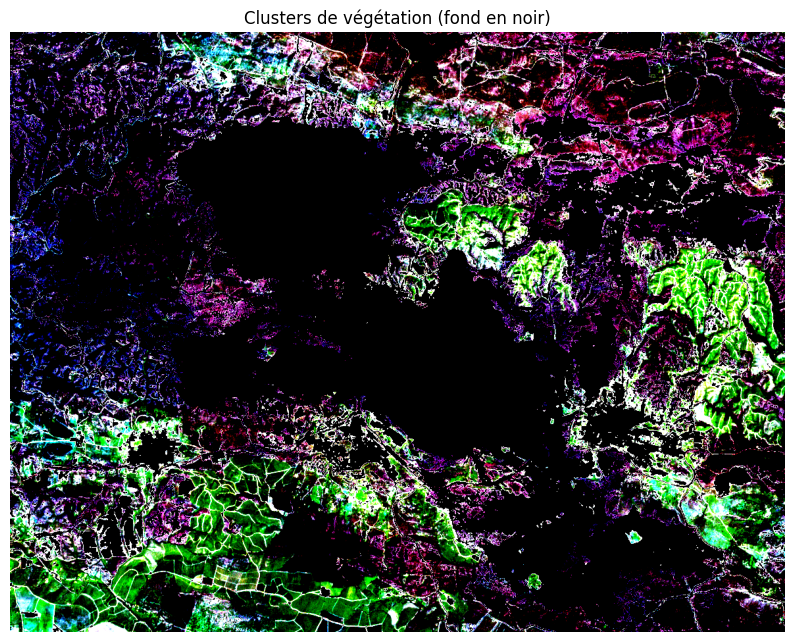

In [ ]:
# Flatten mask
"""
veg_idx = veg_mask.flatten()

pixels = image.reshape(l, -1).T      # → (H*W, C)
veg_pixels = pixels[veg_idx]         # → (N_veg, C)
"""

image_path = r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_10m.img'
raster_img = rio.open(image_path)
arr_img = reshape_as_image(raster_img.read())  # (m, n, l)
image = reshape_as_raster(arr_img)
l, m, n = image.shape

veg_mask_2d = (vegetation_only[:, :, 0] != 0)  # prendre la première bande uniquement
veg_mask_1d = veg_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
veg_pixels = pixels[veg_mask_1d]             # (N_veg, l) → uniquement végétation

scaler = StandardScaler()
X_scaled_veg = scaler.fit_transform(veg_pixels)
#print(X_scaled_veg.shape)
img_scaled_veg_complete = pixels.copy()
img_scaled_veg_complete[veg_mask_1d] = X_scaled_veg
img_scaled_veg_complete[~veg_mask_1d] = np.mean(X_scaled_veg)

# --- 9) Affichage ---
plt.figure(figsize=(10,10))
plt.imshow(img_scaled_veg_complete.reshape(m,n,l)[:,:,:3])
plt.axis('off')
plt.title("Clusters de végétation (fond en noir)")
plt.show()


In [12]:
inertias = []
    #sil_scores = []

K_range = range(2, 20, 1)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
    kmeans.fit(X_scaled_veg)
    inertias.append(kmeans.inertia_)
    #print("Done")

plt.plot(K_range, inertias, marker='o')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (somme des distances)')
plt.title('Méthode du coude')
plt.show()

knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
optimal_k = knee.knee

print(f"k optimal trouvé = {optimal_k}")

KeyboardInterrupt: 

Silhouette (échantillon) pour k = 5 : 0.321
Calinski-Harabasz pour k = 5 : 507210.97


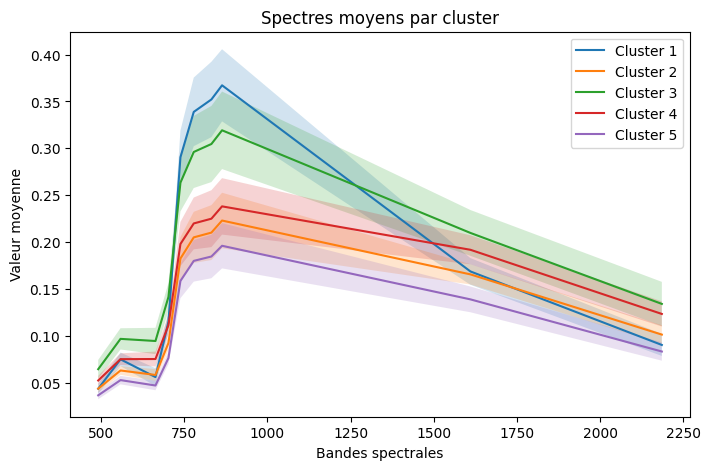

In [19]:
optimal_k = 5
# --- 6) K-Means final avec k optimal ---
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
labels_veg = kmeans_final.fit_predict(X_scaled_veg)

max_samples = 20000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled_veg.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled_veg = X_scaled_veg[idx]
    labels_sampled_veg = labels_veg[idx]
else:
    X_sampled_veg = X_scaled_veg
    labels_sampled_veg = labels_veg

sil_score = silhouette_score(X_sampled_veg, labels_sampled_veg)
ch_score  = calinski_harabasz_score(X_scaled_veg, labels_veg)

print(f"Silhouette (échantillon) pour k = {optimal_k} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {optimal_k} : {ch_score:.2f}")

# Calcul des moyennes par cluster
mean_spectra = np.zeros((optimal_k, veg_pixels.shape[1]))
std_spectra = np.zeros((optimal_k, veg_pixels.shape[1]))

for k in range(optimal_k):
    cluster_pixels = pixels[veg_mask_1d][labels_veg == k]
    mean_spectra[k] = cluster_pixels.mean(axis=0)
    std_spectra[k]  = cluster_pixels.std(axis=0)

# Option : afficher sous forme de tableau avec pandas
df_mean_spectra = pd.DataFrame(
    mean_spectra, 
    columns=[f'Bande_{i+1}' for i in range(veg_pixels.shape[1])]
)
df_mean_spectra.index = [f'Cluster_{i+1}' for i in range(optimal_k)]

#print(df_mean_spectra)

plt.figure(figsize=(8,5))
bands = np.array([492, 559, 664, 703, 739, 779, 832, 864, 1610,  2185])

for k in range(optimal_k):
    plt.plot(bands, mean_spectra[k], label=f'Cluster {k+1}')
    plt.fill_between(
        bands,
        mean_spectra[k] - std_spectra[k],
        mean_spectra[k] + std_spectra[k],
        alpha=0.2
    )
plt.xlabel('Bandes spectrales')
plt.ylabel('Valeur moyenne')
plt.title('Spectres moyens par cluster')
plt.legend()
plt.show()

6 classes pour la végétation selon le critère du coude

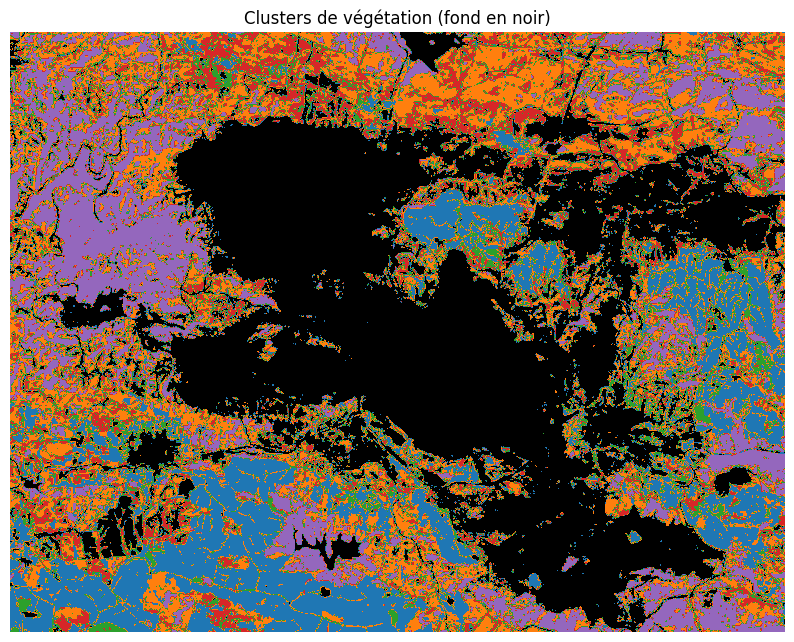

In [14]:
# --- 7) Construction de la carte finale ---
cluster_map = np.zeros((m, n), dtype=int)
cluster_map[veg_mask_2d] = labels_veg + 1  # 0 = fond, clusters à partir de 1

# --- 8) Création de la colormap ---
cmap_colors = ["black"] + list(plt.cm.tab10.colors[:optimal_k])
cmap = colors.ListedColormap(cmap_colors)

# --- 9) Affichage ---
plt.figure(figsize=(10,10))
plt.imshow(cluster_map, cmap=cmap)
plt.axis('off')
plt.title("Clusters de végétation (fond en noir)")
plt.show()

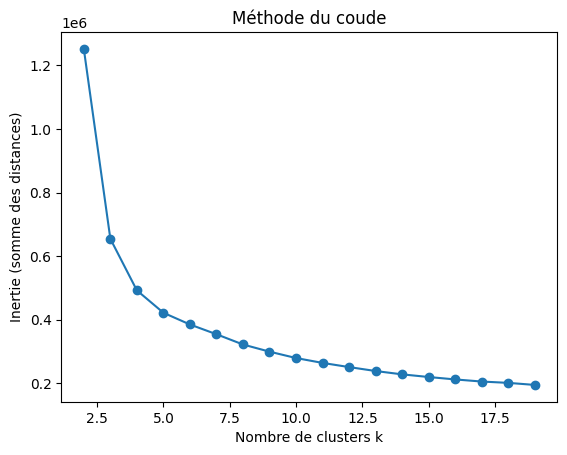

k optimal trouvé = 5


In [21]:
other_mask_2d = (soil_only[:, :, 0] == 0) & (vegetation_only[:,:,0]== 0)  # prendre la première bande uniquement
other_mask_1d = other_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
other_pixels = pixels[other_mask_1d]             

scaler = StandardScaler()
X_scaled_other = scaler.fit_transform(other_pixels)

img_scaled_other_complete = pixels.copy()
img_scaled_other_complete[other_mask_1d] = X_scaled_other
img_scaled_other_complete[~other_mask_1d] = np.mean(X_scaled_other)

inertias = []

K_range = range(2, 20, 1)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
    kmeans.fit(X_scaled_other)
    inertias.append(kmeans.inertia_)
    #print("Done")

plt.plot(K_range, inertias, marker='o')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (somme des distances)')
plt.title('Méthode du coude')
plt.show()

knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
optimal_k = knee.knee

print(f"k optimal trouvé = {optimal_k}")


In [ ]:
inertias = []

K_range = range(2, 20, 1)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
    kmeans.fit(X_scaled_other)
    inertias.append(kmeans.inertia_)
    #print("Done")

plt.plot(K_range, inertias, marker='o')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (somme des distances)')
plt.title('Méthode du coude')
plt.show()

knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
optimal_k = knee.knee

print(f"k optimal trouvé = {optimal_k}")

5 classes pour le reste selon le critère du coude

X_scaled shape : (234214, 10)
labels shape   : (234214,)
labels uniques : {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4)}
Silhouette (échantillon) pour k = 5 : 0.307
Calinski-Harabasz pour k = 5 : 266786.00


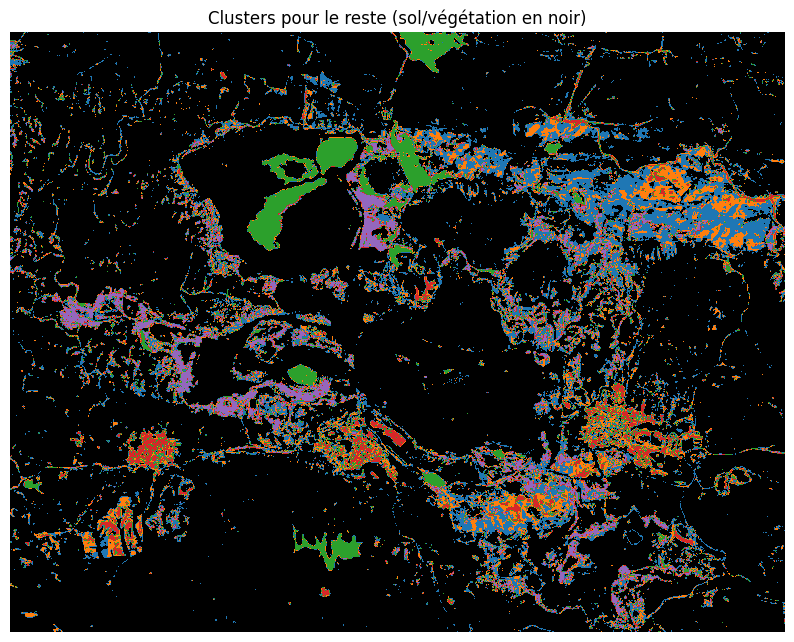

In [17]:
optimal_k = 5

# --- 6) K-Means final avec k optimal ---
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
labels_other = kmeans_final.fit_predict(X_scaled_other)

print("X_scaled shape :", X_scaled_other.shape)
print("labels shape   :", labels_other.shape)
print("labels uniques :", set(labels_other))

max_samples = 20000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled_other.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled = X_scaled_other[idx]
    labels_sampled = labels_other[idx]
else:
    X_sampled = X_scaled_other
    labels_sampled = labels_other

sil_score = silhouette_score(X_sampled, labels_sampled)
ch_score  = calinski_harabasz_score(X_scaled_other, labels_other)

print(f"Silhouette (échantillon) pour k = {optimal_k} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {optimal_k} : {ch_score:.2f}")

# --- 7) Construction de la carte finale ---
cluster_map = np.zeros((m, n), dtype=int)
cluster_map[other_mask_2d] = labels_other + 1  # 0 = fond, clusters à partir de 1

# nombre de clusters sol
K = labels_other.max() + 1

# Création d'une colormap : noir pour 0, puis couleurs distinctes
cmap_colors = ["black"] + list(plt.cm.tab10.colors[:K])
cmap = colors.ListedColormap(cmap_colors)

plt.figure(figsize=(10, 10))
plt.imshow(cluster_map, cmap=cmap)
plt.title("Clusters pour le reste (sol/végétation en noir)")
plt.axis("off")
plt.show()

In [23]:
# Flatten mask

image_path = r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_10m.img'
raster_img = rio.open(image_path)
arr_img = reshape_as_image(raster_img.read())  # (m, n, l)
image = reshape_as_raster(arr_img)
l, m, n = image.shape

soil_mask_2d = (soil_only[:, :, 0] != 0)  # prendre la première bande uniquement
soil_mask_1d = soil_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = image.reshape(l, -1).T   
soil_pixels = pixels[soil_mask_1d]     

scaler = StandardScaler()
X_scaled_soil = scaler.fit_transform(soil_pixels)

img_scaled_soil_complete = pixels.copy()
img_scaled_soil_complete[soil_mask_1d] = X_scaled_soil
img_scaled_soil_complete[~soil_mask_1d] = np.mean(X_scaled_soil)


In [ ]:
inertias = []

K_range = range(2, 15, 1)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
    kmeans.fit(X_scaled_soil)
    inertias.append(kmeans.inertia_)
    #print("Done")

plt.plot(K_range, inertias, marker='o')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (somme des distances)')
plt.title('Méthode du coude')
plt.show()

knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
optimal_k = knee.knee

print(f"k optimal trouvé = {optimal_k}")

5 classes pour le sol SELON LE CRITERE DU COUDE

       Cluster  Mean_std_all_bands
0    Cluster 1            0.010809
1    Cluster 2            0.014668
2    Cluster 3            0.020446
3    Cluster 4            0.012034
4    Cluster 5            0.016179
5    Cluster 6            0.010500
6    Cluster 7            0.017639
7    Cluster 8            0.015319
8    Cluster 9            0.007903
9   Cluster 10            0.011293
10  Cluster 11            0.040235
11  Cluster 12            0.023107
12  Cluster 13            0.008806
13  Cluster 14            0.012358
14  Cluster 15            0.017366
15  Cluster 16            0.008509
16  Cluster 17            0.011190
17  Cluster 18            0.032611
18  Cluster 19            0.015010
19  Cluster 20            0.012864
20  Cluster 21            0.011788
21  Cluster 22            0.024315
22  Cluster 23            0.012278
23  Cluster 24            0.013513
24  Cluster 25            0.011677
25  Cluster 26            0.017826
26  Cluster 27            0.008732
27  Cluster 28      

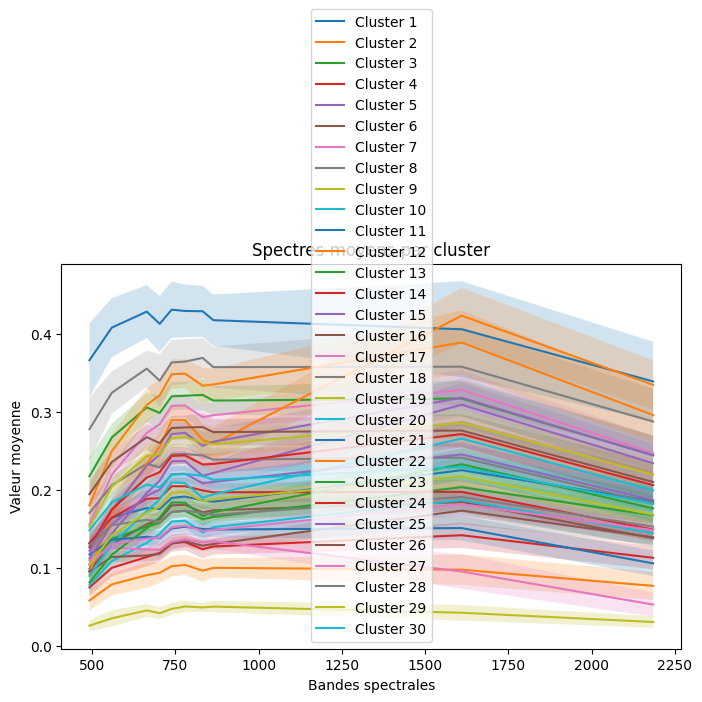

In [24]:
optimal_k = 30

# --- 6) K-Means final avec k optimal ---
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
labels_soil = kmeans_final.fit_predict(X_scaled_soil)

# Calcul des moyennes par cluster
mean_spectra = np.zeros((optimal_k, soil_pixels.shape[1]))
std_spectra = np.zeros((optimal_k, soil_pixels.shape[1]))
mean_std_per_cluster = np.zeros(optimal_k)

for k in range(optimal_k):
    cluster_pixels = soil_pixels[labels_soil == k]
    mean_spectra[k] = cluster_pixels.mean(axis=0)
    std_spectra[k]  = cluster_pixels.std(axis=0)
    mean_std_per_cluster[k] = std_spectra[k].mean() # moyenne de l'écart-type sur toutes les bandes

# Affichage sous forme de DataFrame
df = pd.DataFrame({
    'Cluster': [f'Cluster {i+1}' for i in range(optimal_k)],
    'Mean_std_all_bands': mean_std_per_cluster
})

# Option : afficher sous forme de tableau avec pandas
df_mean_spectra = pd.DataFrame(
    mean_spectra, 
    columns=[f'Bande_{i+1}' for i in range(soil_pixels.shape[1])]
)

print(df)
df_mean_spectra.index = [f'Cluster_{i+1}' for i in range(optimal_k)]

print(df_mean_spectra)

plt.figure(figsize=(8,5))
bands = np.array([492, 559, 664, 703, 739, 779, 832, 864, 1610,  2185])

for k in range(optimal_k):
    plt.plot(bands, mean_spectra[k], label=f'Cluster {k+1}')
    plt.fill_between(
        bands,
        mean_spectra[k] - std_spectra[k],
        mean_spectra[k] + std_spectra[k],
        alpha=0.2
    )
plt.xlabel('Bandes spectrales')
plt.ylabel('Valeur moyenne')
plt.title('Spectres moyens par cluster')
plt.legend()
plt.show()

Silhouette (échantillon) pour k = 30 : 0.213
Calinski-Harabasz pour k = 30 : 88485.45


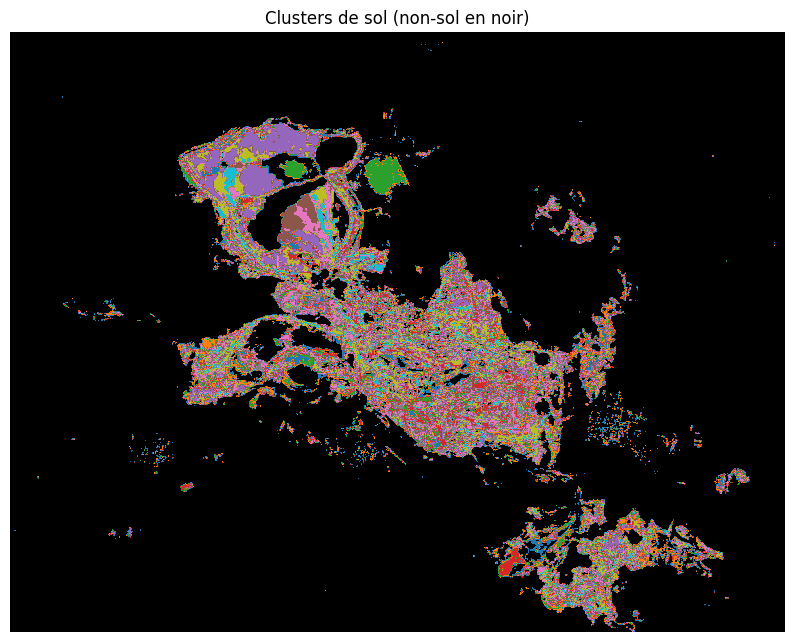

In [25]:
import matplotlib.colors as colors

k_soil = 30
kmeans = KMeans(n_clusters=k_soil, random_state=42)
labels = kmeans.fit_predict(X_scaled_soil)

max_samples = 20000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled_soil.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled = X_scaled_soil[idx]
    labels_sampled = labels_soil[idx]
else:
    X_sampled = X_scaled_soil
    labels_sampled = labels_soil

sil_score = silhouette_score(X_sampled, labels_sampled)
ch_score  = calinski_harabasz_score(X_scaled_soil, labels_soil)

print(f"Silhouette (échantillon) pour k = {k_soil} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {k_soil} : {ch_score:.2f}")

# Carte vide
cluster_map = np.zeros((m, n), dtype=int) 

# On "injecte" les labels K-means dans la carte finale
cluster_map[soil_mask_2d] = labels + 1

# nombre de clusters végétation
K = labels.max() + 1

# Création d'une colormap : noir pour 0, puis couleurs distinctes
cmap_colors = ["black"] + list(plt.cm.tab10.colors[:K])
cmap = colors.ListedColormap(cmap_colors)

plt.figure(figsize=(10, 10))
plt.imshow(cluster_map, cmap=cmap)
plt.title("Clusters de sol (non-sol en noir)")
plt.axis("off")
plt.show()

In [26]:
class LinearAutoencoder(nn.Module):
    def __init__(self, in_dim, latent_dim):
        super().__init__()

        # ----- Encodeur -----
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        # ----- Décodeur -----
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, in_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z

In [27]:
def train_autoencoder(model, dataloader, epochs, criterion, optimizer, device):
    for ep in range(epochs):
        model.train()
        loss_sum = 0
        for x, in dataloader:
            x = x.to(device)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        print(f"Epoch {ep+1}/{epochs}   Loss = {loss_sum/len(dataloader):.6f}")

In [28]:
def encode_all(model, dataloader, device):
    model.eval()
    latents = []

    with torch.no_grad():
        for x, in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

In [29]:
import matplotlib.colors as mcolors

def get_n_colors(n):
    base = plt.cm.get_cmap("tab20")   # ou "nipy_spectral", "viridis", etc.
    colors = base(np.linspace(0, 1, n))
    return mcolors.ListedColormap(colors)

In [30]:
if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 4               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor_veg = torch.tensor(X_scaled_veg, dtype=torch.float32)
    dataset = TensorDataset(X_tensor_veg.T.reshape(l, -1).T)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=256, shuffle=False)

    # ------------------------------------------------------------------
    # Autoencodeur
    # ------------------------------------------------------------------
    model = LinearAutoencoder(BANDS, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Entraînement
    train_autoencoder(model, loader, EPOCHS, criterion, optimizer, DEVICE)

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    latent_vectors = encode_all(model, loader_ordered, DEVICE)   # shape = (H*W, LATENT_DIM)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters_veg = 5
    kmeans = KMeans(n_clusters_veg, n_init=5, random_state=0)
    labels_1d_veg = kmeans.fit_predict(latent_vectors)

    """
    classification_map = labels_1d_veg.reshape(H, W)

    # ------------------------------------------------------------------
    # Affichage
    # ------------------------------------------------------------------
    cmapK = get_n_colors(n_clusters)

    plt.figure(figsize=(6, 6))
    plt.imshow(classification_map, cmap=cmapK)
    plt.title("Classification K-means dans l'espace latent")
    plt.colorbar()
    plt.show()
    """

max_samples = 20000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled_veg.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled_veg = X_scaled_veg[idx]
    labels_sampled_veg = labels_1d_veg[idx]
else:
    X_sampled_veg = X_scaled_veg
    labels_sampled_veg = labels_1d_veg

sil_score = silhouette_score(X_sampled_veg, labels_sampled_veg)
ch_score  = calinski_harabasz_score(X_sampled_veg, labels_sampled_veg)

print(f"Silhouette (échantillon) pour k = {n_clusters_veg} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {n_clusters_veg} : {ch_score:.2f}")

Epoch 1/5   Loss = 0.539427
Epoch 2/5   Loss = 0.526122
Epoch 3/5   Loss = 0.525503
Epoch 4/5   Loss = 0.525235
Epoch 5/5   Loss = 0.525044
Silhouette (échantillon) pour k = 5 : 0.274
Calinski-Harabasz pour k = 5 : 12292.37


In [31]:
if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 4               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor_soil = torch.tensor(X_scaled_soil, dtype=torch.float32)
    dataset = TensorDataset(X_tensor_soil.T.reshape(l, -1).T)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=256, shuffle=False)

    # ------------------------------------------------------------------
    # Autoencodeur
    # ------------------------------------------------------------------
    model = LinearAutoencoder(BANDS, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Entraînement
    train_autoencoder(model, loader, EPOCHS, criterion, optimizer, DEVICE)

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    latent_vectors = encode_all(model, loader_ordered, DEVICE)   # shape = (H*W, LATENT_DIM)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters_soil = 30
    kmeans = KMeans(n_clusters_soil, n_init=5, random_state=0)
    labels_1d_soil = kmeans.fit_predict(latent_vectors)

    """
    classification_map = labels_1d_veg.reshape(H, W)

    # ------------------------------------------------------------------
    # Affichage
    # ------------------------------------------------------------------
    cmapK = get_n_colors(n_clusters)

    plt.figure(figsize=(6, 6))
    plt.imshow(classification_map, cmap=cmapK)
    plt.title("Classification K-means dans l'espace latent")
    plt.colorbar()
    plt.show()
    """

max_samples = 20000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled_soil.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled_soil = X_scaled_soil[idx]
    labels_sampled_soil = labels_1d_soil[idx]
else:
    X_sampled_soil = X_scaled_soil
    labels_sampled_soil = labels_1d_soil

sil_score = silhouette_score(X_sampled_soil, labels_sampled_soil)
ch_score  = calinski_harabasz_score(X_sampled_soil, labels_sampled_soil)

print(f"Silhouette (échantillon) pour k = {n_clusters_soil} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {n_clusters_soil} : {ch_score:.2f}")

Epoch 1/5   Loss = 0.625827
Epoch 2/5   Loss = 0.586054
Epoch 3/5   Loss = 0.583799
Epoch 4/5   Loss = 0.583233
Epoch 5/5   Loss = 0.583094
Silhouette (échantillon) pour k = 30 : 0.164
Calinski-Harabasz pour k = 30 : 9082.00


In [32]:
if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 4               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor_other = torch.tensor(X_scaled_other, dtype=torch.float32)
    dataset = TensorDataset(X_tensor_other.T.reshape(l, -1).T)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=256, shuffle=False)

    # ------------------------------------------------------------------
    # Autoencodeur
    # ------------------------------------------------------------------
    model = LinearAutoencoder(BANDS, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Entraînement
    train_autoencoder(model, loader, EPOCHS, criterion, optimizer, DEVICE)

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    latent_vectors = encode_all(model, loader_ordered, DEVICE)   # shape = (H*W, LATENT_DIM)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters_other = 5
    kmeans = KMeans(n_clusters_other, n_init=5, random_state=0)
    labels_1d_other = kmeans.fit_predict(latent_vectors)

    """
    classification_map = labels_1d_veg.reshape(H, W)

    # ------------------------------------------------------------------
    # Affichage
    # ------------------------------------------------------------------
    cmapK = get_n_colors(n_clusters)

    plt.figure(figsize=(6, 6))
    plt.imshow(classification_map, cmap=cmapK)
    plt.title("Classification K-means dans l'espace latent")
    plt.colorbar()
    plt.show()
    """

max_samples = 20000  # à ajuster si tu veux plus ou moins de précision
n_samples = X_scaled_other.shape[0]

if n_samples > max_samples:
    idx = np.random.choice(n_samples, max_samples, replace=False)
    X_sampled_other = X_scaled_other[idx]
    labels_sampled_other = labels_1d_other[idx]
else:
    X_sampled_other = X_scaled_other
    labels_sampled_other = labels_1d_other

sil_score = silhouette_score(X_sampled_other, labels_sampled_other)
ch_score  = calinski_harabasz_score(X_sampled_other, labels_sampled_other)

print(f"Silhouette (échantillon) pour k = {n_clusters_other} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {n_clusters_other} : {ch_score:.2f}")

Epoch 1/5   Loss = 0.657116
Epoch 2/5   Loss = 0.625732
Epoch 3/5   Loss = 0.624627
Epoch 4/5   Loss = 0.624152
Epoch 5/5   Loss = 0.623875
Silhouette (échantillon) pour k = 5 : 0.284
Calinski-Harabasz pour k = 5 : 21502.63


In [ ]:
"""
class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=128, input_size=128):
    
        super(ConvAutoencoder, self).__init__()

        # ------- ENCODER -------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, 2, 1),  # H/2
            nn.ReLU(True),

            nn.Conv2d(32, 64, 3, 2, 1),           # H/4
            nn.ReLU(True),

            nn.Conv2d(64, 128, 3, 2, 1),          # H/8
            nn.ReLU(True),

            nn.Conv2d(128, 256, 3, 2, 1),         # H/16
            nn.ReLU(True),
        )

        # Calculer la taille du tenseur après convolutions
        conv_out_size = 256 * (input_size // 16) * (input_size // 16)

        # ------- LATENT VECTOR -------
        self.fc_enc = nn.Linear(conv_out_size, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, conv_out_size)

        # ------- DECODER -------
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, 2, 1, 1),  # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 3, 2, 1, 1),   # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 3, 2, 1, 1),    # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(32, in_channels, 3, 2, 1, 1),  # H*2
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encoder
        z = self.encoder_conv(x)
        batch_size = z.size(0)
        z = z.view(batch_size, -1)        # Flatten
        z = self.fc_enc(z)                # Latent vector

        # Decoder
        z = self.fc_dec(z)
        z = z.view(batch_size, 256, x.size(2)//16, x.size(3)//16)  # reshape pour decoder
        x_recon = self.decoder_conv(z)
        return x_recon
"""

'\nclass ConvAutoencoder(nn.Module):\n    def __init__(self, in_channels=3, latent_dim=128, input_size=128):\n    \n        super(ConvAutoencoder, self).__init__()\n\n        # ------- ENCODER -------\n        self.encoder_conv = nn.Sequential(\n            nn.Conv2d(in_channels, 32, 3, 2, 1),  # H/2\n            nn.ReLU(True),\n\n            nn.Conv2d(32, 64, 3, 2, 1),           # H/4\n            nn.ReLU(True),\n\n            nn.Conv2d(64, 128, 3, 2, 1),          # H/8\n            nn.ReLU(True),\n\n            nn.Conv2d(128, 256, 3, 2, 1),         # H/16\n            nn.ReLU(True),\n        )\n\n        # Calculer la taille du tenseur après convolutions\n        conv_out_size = 256 * (input_size // 16) * (input_size // 16)\n\n        # ------- LATENT VECTOR -------\n        self.fc_enc = nn.Linear(conv_out_size, latent_dim)\n        self.fc_dec = nn.Linear(latent_dim, conv_out_size)\n\n        # ------- DECODER -------\n        self.decoder_conv = nn.Sequential(\n            nn.Conv

In [66]:
class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels, latent_dim=10):
        super().__init__()
        self.latent_dim = latent_dim
        # Encodeur
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),        
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),        
            nn.Conv2d(64, latent_dim, 3, padding=1),
            nn.ReLU()                  
        )
        # Décodeur
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 64, 2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),
            nn.Conv2d(32, in_channels, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent_map = self.encoder(x)
        latent = latent_map.view(x.size(0), -1)
        out = self.decoder(latent_map)
        out = out[:, :, :x.size(2), :x.size(3)]  
        return out, latent

    def encode(self, x):
        latent_map = self.encoder(x)
        latent = latent_map.view(latent_map.size(0), -1)
        return latent

In [34]:
class PatchDataset(Dataset):
    def __init__(self, cube, patch_size):
        """
        cube        : tensor [bands, H, W]
        patch_size  : int
        """
        self.cube = cube
        self.patch = patch_size
        self.pad = patch_size // 2

        # padding pour ne pas perdre les bords
        self.cube_pad = F.pad(cube, (self.pad, self.pad, self.pad, self.pad))

        self.H, self.W = cube.shape[1], cube.shape[2]

    def __len__(self):
        return self.H * self.W

    def __getitem__(self, idx):
        h = idx // self.W
        w = idx % self.W

        patch = self.cube_pad[:, 
                              h : h + 2*self.pad + 1,
                              w : w + 2*self.pad + 1]

        return patch   # shape = [bands, patch, patch]

In [35]:
def encode_all(model, dataloader, device):
    model.eval()
    latents = []

    with torch.no_grad():
        for x in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

In [77]:
PATCH_SIZE = 16
STRIDE = 4
BATCH_SIZE = 128
LATENT_DIM = 6
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_CLUSTERS = 5
# ----------------------------------------------------------
# Préparer les patchs glissants
# ----------------------------------------------------------
def extract_valid_patches_with_mask(image, mask, patch_size=16, stride=8, min_fraction=0.8):
    """
    Extrait des patchs valides selon un masque.
    
    image : [C,H,W]
    mask  : [H,W] ou [1,H,W], bool ou 0/1
    """
    if mask.dim() == 3:
        mask = mask[0]  # si mask [1,H,W]
    
    C, H, W = image.shape
    patches = []
    positions = []

    for i in range(0, H-patch_size+1, stride):
        for j in range(0, W-patch_size+1, stride):
            patch_mask = mask[i:i+patch_size, j:j+patch_size]
            valid_fraction = patch_mask.float().mean().item()
            if valid_fraction >= min_fraction:
                patch = image[:, i:i+patch_size, j:j+patch_size]
                patches.append(patch.unsqueeze(0))
                positions.append((i,j))
    
    if len(patches) > 0:
        patch_tensor = torch.cat(patches, dim=0)
    else:
        patch_tensor = torch.empty(0, C, patch_size, patch_size)
    
    return patch_tensor, positions


# ----------------------------------------------------------
# Exemple : image hyperspectrale
# img_scaled_veg_complete : [C,H,W]
# ----------------------------------------------------------
C, H, W = l,m,n
patch_tensor, positions = extract_valid_patches_with_mask(torch.Tensor(img_scaled_veg_complete.T.reshape(l,m,n)), torch.Tensor(veg_mask_2d), PATCH_SIZE, STRIDE)
print(f"Nombre de patchs valides : {len(patch_tensor)}")

dataset = TensorDataset(patch_tensor)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# ----------------------------------------------------------
# Instancier AE
# ----------------------------------------------------------
model = ConvAutoencoder(in_channels=C, latent_dim=LATENT_DIM).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ----------------------------------------------------------
# Entraînement simple
# ----------------------------------------------------------
for ep in range(EPOCHS):
    model.train()
    running_loss = 0
    for batch in loader:
        x = batch[0].to(DEVICE)
        optimizer.zero_grad()
        out, _ = model(x)
        loss = criterion(out, x)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {ep+1}/{EPOCHS} Loss: {running_loss/len(loader):.6f}")

Nombre de patchs valides : 33573
Epoch 1/5 Loss: 0.678817
Epoch 2/5 Loss: 0.560625
Epoch 3/5 Loss: 0.551629
Epoch 4/5 Loss: 0.539775
Epoch 5/5 Loss: 0.535495


In [80]:
# ----------------------
# Extraction des latents
# ----------------------
model.eval()
all_latents = []
with torch.no_grad():
    for batch in DataLoader(patch_tensor, batch_size=BATCH_SIZE, shuffle=False):
        x = batch[0].to(DEVICE)
        latent = model.encode(x)
        all_latents.append(latent.cpu().numpy())
latent_vectors = np.concatenate(all_latents, axis=0)

# ----------------------
# K-means sur les latents
# ----------------------
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=5, random_state=0)
patch_labels = kmeans.fit_predict(latent_vectors)

# ----------------------
# Vote majoritaire pixel par pixel (gestion bords)
# ----------------------
H, W = m,n
label_votes = np.zeros((H, W, N_CLUSTERS), dtype=int)

for idx in range(len(patch_labels)):
    i, j = positions[idx]
    label = patch_labels[idx]
    # s'assurer que le patch ne dépasse pas les bords
    i_end = min(i+PATCH_SIZE, H)
    j_end = min(j+PATCH_SIZE, W)
    label_votes[i:i_end, j:j_end, label] += 1

classification_map = label_votes.argmax(axis=-1)  # carte finale pixel par pixel
classification_map[veg_mask_2d==0] = -1  # pixels invalides

# ----------------------
# Évaluation non supervisée
# ----------------------
pixels_flat = img_scaled_veg_complete[veg_mask_1d]
labels_flat = classification_map.flatten()[veg_mask_1d]

# ----------------------
# Sous-échantillonnage pour Silhouette
# ----------------------
N_SAMPLE = 20000
if len(pixels_flat) > N_SAMPLE:
    idx_sample = np.random.choice(len(pixels_flat), N_SAMPLE, replace=False)
    pixels_sample = pixels_flat[idx_sample]
    labels_sample = labels_flat[idx_sample]
else:
    pixels_sample = pixels_flat
    labels_sample = labels_flat

sil_score = silhouette_score(pixels_sample, labels_sample)
ch_score  = calinski_harabasz_score(pixels_sample, labels_sample)
print(f"Silhouette: {sil_score:.3f}, Calinski-Harabasz: {ch_score:.2f}")

Silhouette: -0.187, Calinski-Harabasz: 12.18


In [48]:
# APPRENTISSAGE

print(img_scaled_veg_complete.shape)

if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 4               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    PATCH_SIZE = 16
    batch_size = 128
    X_tensor_veg = torch.tensor(img_scaled_veg_complete, dtype=torch.float32)
    dataset = PatchDataset(X_tensor_veg.T.reshape(l,m,n), PATCH_SIZE)
    loader = DataLoader(dataset, batch_size, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size, shuffle=False)

    model = ConvAutoencoder(in_channels=l).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    total_idx = []
    n_batches = 10
    all_latents = []

    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0

            # Échantillonnage aléatoire de n_batches*batch_size indices
        dataset_size = len(dataset)
        n_samples = min(n_batches * batch_size, dataset_size)
        idx = np.random.choice(dataset_size, n_samples, replace=False)
        total_idx.extend(idx)
        
        # Subset + DataLoader
        subset_loader = DataLoader(Subset(dataset, idx), batch_size=batch_size, shuffle=True)

        for  batch_idx, x in enumerate(subset_loader):
            x = x.to(DEVICE)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

                # Affichage en temps réel
            if batch_idx % 1 == 0 or batch_idx == n_batches - 1:
                # \r permet d'écraser la ligne précédente
                print(f"\rEpoch {ep+1}/{EPOCHS}  Batch {batch_idx+1}/{n_batches}  Loss: {loss.item():.6f}", end="")
                sys.stdout.flush()

        print(f"Epoch {ep+1}/{EPOCHS}   Loss = {loss_sum/len(subset_loader):.6f}")

        # Extraction latents pour cette epoch
        epoch_latents = encode_all(model, subset_loader, DEVICE)
        all_latents.append(epoch_latents)
    
    # Fusion des latents
    latent_vectors = np.concatenate(all_latents, axis=0)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters_veg = 5
    kmeans = KMeans(n_clusters_veg, n_init=5, random_state=0)
    labels_1d_veg = kmeans.fit_predict(latent_vectors)

    #classification_map = labels_1d_veg.reshape(H, W)

X_sampled_veg = X_tensor_veg[total_idx]
labels_sampled_veg = labels_1d_veg

sil_score = silhouette_score(latent_vectors, labels_sampled_veg)
ch_score  = calinski_harabasz_score(latent_vectors, labels_sampled_veg)

print(f"Silhouette (échantillon) pour k = {n_clusters_veg} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {n_clusters_veg} : {ch_score:.2f}")

(1074336, 10)


C:\Users\arman\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([128, 10, 17, 17])) that is different to the input size (torch.Size([128, 10, 16, 16])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (16) must match the size of tensor b (17) at non-singleton dimension 3

In [46]:
from collections import defaultdict

# --------------------------------------------------------------
# Hypothèse : tu as déjà
# - img_scaled_veg_complete : image hyperspectrale [C, H, W]
# - ConvAutoencoder : ton autoencodeur
# - encode_all : fonction qui encode un DataLoader en latents
# --------------------------------------------------------------

BATCH_SIZE = 128
STRIDE = 8   # stride < PATCH_SIZE pour chevauchement
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(img_scaled_veg_complete.shape)
# Tensor image
C, H, W = l,m,n
X_tensor_veg = torch.tensor(img_scaled_veg_complete.reshape(-1,m,n), dtype=torch.float32)

# ------------------------------------------------------------------
# 1️⃣ Générer les patchs glissants
# ------------------------------------------------------------------
patches = []
positions = []

for i in range(0, H-PATCH_SIZE+1, STRIDE):
    for j in range(0, W-PATCH_SIZE+1, STRIDE):
        patch = X_tensor_veg[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE]  # [C, P, P]
        patches.append(patch.unsqueeze(0))  # ajouter dim batch
        positions.append((i,j))

patch_tensor = torch.cat(patches, dim=0)  # [n_patches, C, P, P]

# DataLoader pour batch
loader = DataLoader(patch_tensor, batch_size=BATCH_SIZE, shuffle=False)

# ------------------------------------------------------------------
# 2️⃣ Extraire latents
# ------------------------------------------------------------------
model.eval()  # pas d'entraînement ici, juste inférence
latents_list = []

with torch.no_grad():
    for x in loader:
        x = x.to(DEVICE)
        _, latents = model(x)  # assume encode renvoie latents en 2e position
        latents_list.append(latents.cpu().numpy())

latent_vectors = np.concatenate(latents_list, axis=0)  # [n_patches, LATENT_DIM]

# ------------------------------------------------------------------
# 3️⃣ K-means sur les latents
# ------------------------------------------------------------------
n_clusters_veg = 5
kmeans = KMeans(n_clusters_veg, n_init=5, random_state=0)
patch_labels = kmeans.fit_predict(latent_vectors)  # un label par patch

# ------------------------------------------------------------------
# 4️⃣ Vote majoritaire pixel par pixel
# ------------------------------------------------------------------
label_votes = np.zeros((H, W, n_clusters_veg), dtype=int)

for idx, (i, j) in enumerate(positions):
    label = patch_labels[idx]
    # Chaque patch vote pour tous ses pixels
    label_votes[i:i+PATCH_SIZE, j:j+PATCH_SIZE, label] += 1

classification_map = label_votes.argmax(axis=-1)  # [H, W]

# ------------------------------------------------------------------
# 5️⃣ Calcul de métriques sur les pixels reconstruits
# ------------------------------------------------------------------
# reconstruire les patchs dans l'espace latent pour silhouette si besoin
# ici, on prend juste les pixels de l'image originale comme référence
pixels_flat = X_tensor_veg.permute(1,2,0).reshape(-1, C).numpy()
labels_flat = classification_map.flatten()

sil_score = silhouette_score(pixels_flat, labels_flat)
ch_score  = calinski_harabasz_score(pixels_flat, labels_flat)

print(f"Silhouette (pixel vote majoritaire) : {sil_score:.3f}")
print(f"Calinski-Harabasz (pixel vote majoritaire) : {ch_score:.2f}")

# classification_map contient maintenant la carte finale pixel par pixel


(1074336, 10)


RuntimeError: mat1 and mat2 shapes cannot be multiplied (128x32768 and 36992x128)

In [ ]:
print(img_scaled_soil_complete.shape)

if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 4               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    PATCH_SIZE = 16
    batch_size = 128
    X_tensor_soil = torch.tensor(img_scaled_soil_complete, dtype=torch.float32)
    dataset = PatchDataset(X_tensor_soil.T.reshape(l,m,n), PATCH_SIZE)
    loader = DataLoader(dataset, batch_size, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size, shuffle=False)

    model = ConvAutoencoder(in_channels=l).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    total_idx = []
    n_batches = 10
    all_latents = []


    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0

            # Échantillonnage aléatoire de n_batches*batch_size indices
        dataset_size = len(dataset)
        n_samples = min(n_batches * batch_size, dataset_size)
        idx = np.random.choice(dataset_size, n_samples, replace=False)
        total_idx.extend(idx)
        
        # Subset + DataLoader
        subset_loader = DataLoader(Subset(dataset, idx), batch_size=batch_size, shuffle=True)

        for  batch_idx, x in enumerate(subset_loader):
            x = x.to(DEVICE)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

                # Affichage en temps réel
            if batch_idx % 1 == 0 or batch_idx == n_batches - 1:
                # \r permet d'écraser la ligne précédente
                print(f"\rEpoch {ep+1}/{EPOCHS}  Batch {batch_idx+1}/{n_batches}  Loss: {loss.item():.6f}", end="")
                sys.stdout.flush()

        print(f"Epoch {ep+1}/{EPOCHS}   Loss = {loss_sum/len(subset_loader):.6f}")

        # Extraction latents pour cette epoch
        epoch_latents = encode_all(model, subset_loader, DEVICE)
        all_latents.append(epoch_latents)
    
    # Fusion des latents
    latent_vectors = np.concatenate(all_latents, axis=0)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters_soil = 30
    kmeans = KMeans(n_clusters_soil, n_init=5, random_state=0)
    labels_1d_soil = kmeans.fit_predict(latent_vectors)

    #classification_map = labels_1d_veg.reshape(H, W)

X_sampled_soil = X_tensor_soil[total_idx]
labels_sampled_soil = labels_1d_soil

sil_score = silhouette_score(latent_vectors, labels_sampled_soil)
ch_score  = calinski_harabasz_score(latent_vectors, labels_sampled_soil)

print(f"Silhouette (échantillon) pour k = {n_clusters_soil} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {n_clusters_soil} : {ch_score:.2f}")

(1074336, 10)
Epoch 1/5  Batch 10/10  Loss: 0.307482Epoch 1/5   Loss = 0.394699
Epoch 2/5  Batch 10/10  Loss: 0.143019Epoch 2/5   Loss = 0.196602
Epoch 3/5  Batch 10/10  Loss: 0.169097Epoch 3/5   Loss = 0.164162
Epoch 4/5  Batch 10/10  Loss: 0.117479Epoch 4/5   Loss = 0.158948
Epoch 5/5  Batch 10/10  Loss: 0.095814Epoch 5/5   Loss = 0.137995
Silhouette (échantillon) pour k = 30 : 0.563
Calinski-Harabasz pour k = 30 : 2122.57


In [ ]:
print(img_scaled_other_complete.shape)

if __name__ == "__main__":

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    LATENT_DIM = 4               # taille espace latent
    EPOCHS = 5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    PATCH_SIZE = 16
    batch_size = 128
    X_tensor_other = torch.tensor(img_scaled_other_complete, dtype=torch.float32)
    dataset = PatchDataset(X_tensor_other.T.reshape(l,m,n), PATCH_SIZE)
    loader = DataLoader(dataset, batch_size, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size, shuffle=False)

    model = ConvAutoencoder(in_channels=l).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    total_idx = []
    n_batches = 10
    all_latents = []


    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0

            # Échantillonnage aléatoire de n_batches*batch_size indices
        dataset_size = len(dataset)
        n_samples = min(n_batches * batch_size, dataset_size)
        idx = np.random.choice(dataset_size, n_samples, replace=False)
        total_idx.extend(idx)
        
        # Subset + DataLoader
        subset_loader = DataLoader(Subset(dataset, idx), batch_size=batch_size, shuffle=True)

        for  batch_idx, x in enumerate(subset_loader):
            x = x.to(DEVICE)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

                # Affichage en temps réel
            if batch_idx % 1 == 0 or batch_idx == n_batches - 1:
                # \r permet d'écraser la ligne précédente
                print(f"\rEpoch {ep+1}/{EPOCHS}  Batch {batch_idx+1}/{n_batches}  Loss: {loss.item():.6f}", end="")
                sys.stdout.flush()

        print(f"Epoch {ep+1}/{EPOCHS}   Loss = {loss_sum/len(subset_loader):.6f}")

        # Extraction latents pour cette epoch
        epoch_latents = encode_all(model, subset_loader, DEVICE)
        all_latents.append(epoch_latents)
    
    # Fusion des latents
    latent_vectors = np.concatenate(all_latents, axis=0)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    n_clusters_other = 5
    kmeans = KMeans(n_clusters_other, n_init=5, random_state=0)
    labels_1d_other = kmeans.fit_predict(latent_vectors)

    #classification_map = labels_1d_veg.reshape(H, W)

labels_sampled_other = labels_1d_other

sil_score = silhouette_score(latent_vectors, labels_sampled_other)
ch_score  = calinski_harabasz_score(latent_vectors, labels_sampled_other)

print(f"Silhouette (échantillon) pour k = {n_clusters_other} : {sil_score:.3f}")
print(f"Calinski-Harabasz pour k = {n_clusters_other} : {ch_score:.2f}")

(1074336, 10)
Epoch 1/5  Batch 10/10  Loss: 0.369645Epoch 1/5   Loss = 0.457443
Epoch 2/5  Batch 10/10  Loss: 0.148737Epoch 2/5   Loss = 0.276662
Epoch 3/5  Batch 10/10  Loss: 0.180379Epoch 3/5   Loss = 0.231405
Epoch 4/5  Batch 10/10  Loss: 0.181905Epoch 4/5   Loss = 0.226636
Epoch 5/5  Batch 10/10  Loss: 0.118172Epoch 5/5   Loss = 0.174426
Silhouette (échantillon) pour k = 5 : 0.788
Calinski-Harabasz pour k = 5 : 6074.06


In [ ]:
print(X_sampled_veg.shape)
print(labels_sampled_veg.shape)
print(len(total_idx))
print(latent_vectors.shape)

torch.Size([6400, 10])
(6400,)
6400
(6400, 128)


Nombre de clusters pour la végétation avec CAH

In [ ]:
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster

N = 20000
idx = np.random.choice(len(X_scaled_veg), N, replace=False)
X_sample = X_scaled_veg[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')


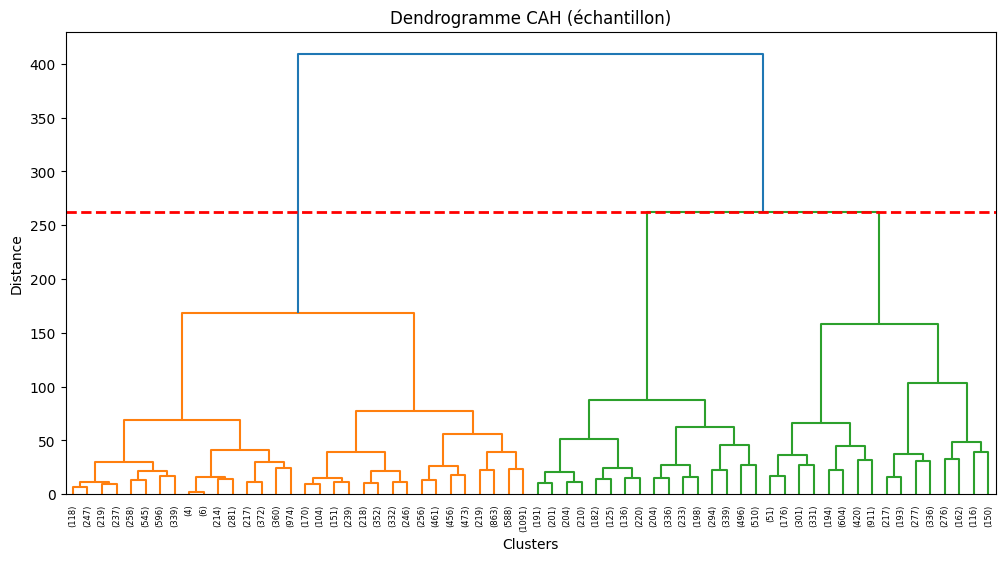

In [ ]:
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

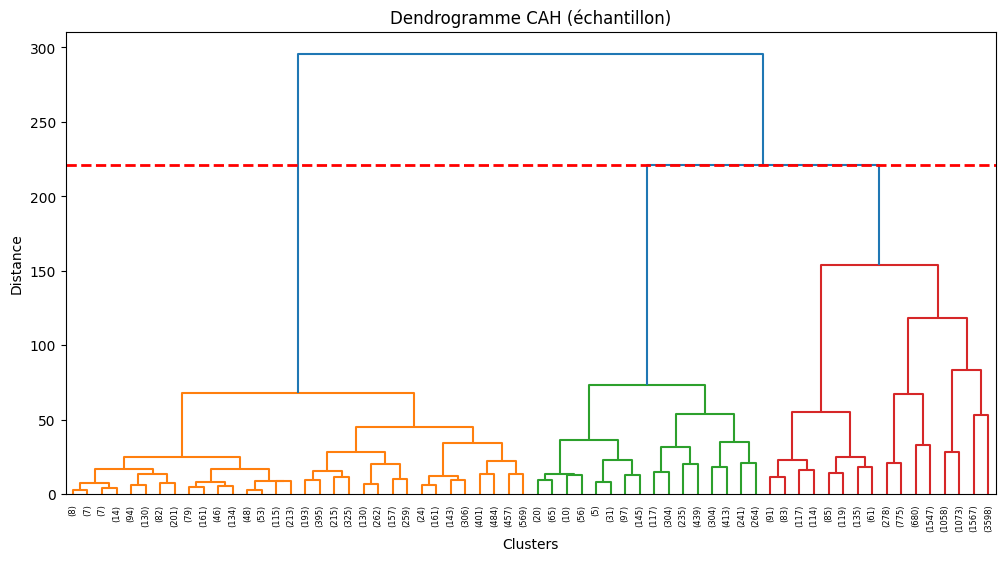

In [ ]:
N = 20000
idx = np.random.choice(len(X_scaled_other), N, replace=False)
X_sample = X_scaled_veg[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()
